# Drug Legalization Difference-in-Difference

In recent years, many US states have decided to legalize the use of marijuana.

When these ideas were first proposed, there were many theories about the relationship between crime and the "War on Drugs" (the term given to US efforts to arrest drug users and dealers over the past several decades).

In this exercise, we're going to test a few of those theories using drug arrest data from the state of California.

Though California has passed a number of laws lessening penalities for marijuana possession over the years, arguably the biggest changes were in  2010, when the state changed the penalty for possessing a small amount of marijuana from a criminal crime to a "civil" penality (meaning those found guilty only had to pay a fine, not go to jail), though possessing, selling, or producing larger quantities remained illegal. Then in 2016, the state fully legalized marijuana for recreational use, not only making possession of small amounts legal, but also creating a regulatory system for producing marijuana for sale.

Proponents of drug legalization have long argued that the war on drugs contributes to violent crime by creating an opportunity for drug dealers and organized crime to sell and distribute drugs, a business which tends to generate violence when gangs battle over territory. According to this theory, with drug legalization, we should see violent crime decrease after legalization in places where drug arrests had previously been common.

**To be clear,** this is far from the only argument for drug legalization! It is simply the argument we are well positioned to analyze today.

(Students from Practical Data Science: This should sound familiar! Last semester we did this analysis in a very simple, crude manner; in this class we'll do it rigorously with your new found difference-in-differences skills!)


## Gradescope Autograding

Please follow [all standard guidance](https://www.practicaldatascience.org/ids720_specific/autograder_guidelines.html) for submitting this assignment to the Gradescope autograder, including storing your solutions in a dictionary called `results` and ensuring your notebook runs from the start to completion without any errors.

For this assignment, please name your file `exercise_diffindiff.ipynb` before uploading.

You can check that you have answers for all questions in your `results` dictionary with this code:

```python
assert set(results.keys()) == {
    "ex2_median",
    "ex4_diff_in_diff",
    "ex4_y_t0_post",
    "ex4_y_t0_pre",
    "ex4_y_t1_post",
    "ex4_y_t1_pre",
    "ex5_interaction_coefficient",
    "ex5_standard_error",
}
```


### Submission Limits

Please remember that you are **only allowed THREE submissions to the autograder.** Your last submission (if you submit 3 or fewer times), or your third submission (if you submit more than 3 times) will determine your grade Submissions that error out will **not** count against this total.

In [ ]:
# !pip install causalpy
# !pip install jupyter-black

In [28]:
# imports
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import causalpy as cp
from sklearn.linear_model import LinearRegression

In [29]:
# import jupyter_black

# jupyter_black.load()

In [30]:
results = {}

## Exercise 1

Download and import California arrest data from [https://github.com/nickeubank/MIDS_Data/blob/master/UDS_arrest_data.csv](https://github.com/nickeubank/MIDS_Data/blob/master/UDS_arrest_data.csv). What is a unit of observation (a single row) in this data? What entities are being tracked, and over what time period?

Note that `VIOLENT` is a count of arrests for violent offenses, and `F_DRUGOFF` is a count of felony drug arrests. `total_population` is total population.

In [31]:
url = (
    "https://github.com/nickeubank/MIDS_Data/raw/refs/heads/master/UDS_arrest_data.csv"
)
data = pd.read_csv(url)
data.head()

,YEAR,COUNTY,VIOLENT,F_DRUGOFF,total_population
0,1980,Alameda County,4504,3569,1105379.0
1,1981,Alameda County,4699,3926,1122759.3
2,1982,Alameda County,4389,4436,1140139.6
3,1983,Alameda County,4500,5086,1157519.9
4,1984,Alameda County,3714,5878,1174900.2


In [32]:
np.unique(data["YEAR"])

array([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
       1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018])

**A single row represents arrest data (number of violent offenses, felony drug arrests, and total pop) for individual counties in California in an individual year. A county in the data has rows from 1980 to 2018, so arrest data per year for each county in the dataset.**

## Exercise 2

In this analysis, we will split our sample into "treated" and "control" counties on the basis of whether a given county had a high average drug arrest rate in the three years before California began drug legalization in 2010. Counties with high drug arrest rates, after all, will be more impacted by drug liberalization policies.

Calculate each county's average drug arrest *rate* for the period from 2007-2009 (including 2007 and 2009). Calculate the rate in arrests *per 100,000* — arrest are relatively rare, so this type of scaling helps avoid chasing decimals.

Then calculate the **median** of these averaged values across counties, and create an indicator called `treated` for counties whose average drug arrest rate during this period was above the median average drug arrest rate. In other words, half your counties should be in the "treated" group, and half in "control".

Note that this indicator should be *time-invariant*—if a county is in the treated group, it should be in the treated group in all years.

Store the median value of drug arrest rates used to separate counties into high and low drug arrest rates in `results` under the key `"ex2_median"`.

In [33]:
# get the arrest rate at county level
data["drug_rate"] = (data["F_DRUGOFF"] / data["total_population"]) * 100000
data_three_years = (
    data[data["YEAR"].between(2007, 2009)][["COUNTY", "drug_rate"]]
    .groupby("COUNTY")
    .mean()
)
data_three_years["Arrest Rate"] = data_three_years["drug_rate"]
median_rate = data_three_years["Arrest Rate"].median()

# indicator for county based on average arrest rate versus median of it
data_three_years["county treated"] = data_three_years["Arrest Rate"] > median_rate
data_three_years.head()

# counties time invariant so treated value should be same across all years, map it back, above is from aggregated from 3 years

counties_treated = data_three_years["county treated"].to_dict()

data["treated"] = data["COUNTY"].map(counties_treated)

data.head()

,YEAR,COUNTY,VIOLENT,F_DRUGOFF,total_population,drug_rate,treated
0,1980,Alameda County,4504,3569,1105379.0,322.875683,True
1,1981,Alameda County,4699,3926,1122759.3,349.674236,True
2,1982,Alameda County,4389,4436,1140139.6,389.075162,True
3,1983,Alameda County,4500,5086,1157519.9,439.387694,True
4,1984,Alameda County,3714,5878,1174900.2,500.297813,True


In [34]:
print("The median value average drug arrest rate is: ", median_rate)
results["ex2_median"] = median_rate

The median value average drug arrest rate is:  301.8092992253924


## Exercise 3

Our outcome in this analysis is the violent arrest rate -- if drug liberalization reduces crime overall, we would expect to see this rate fall in counties with high drug arrest rates after liberalization; if not, we would not expect to see any changes. Create a `violent_rate` variable with is violent arrests per 100,000 people.

In [35]:
data["violent_rate"] = data["VIOLENT"] / data["total_population"] * 100000

## Exercise 4

Differences-in-differences get their name from the fact that the estimator, in its most basic implementation, is just the difference between:

-  difference in the average change in outcome among eventually-treated units from before to after when treatment is applied, and
-  difference in the average change in outcome among never-treated units from before to after when treatment (to the treated units).

(Obviously treatment is never a applied to the never-treated units -- when we talk about pre / post, we refer to before and after the point in time in which treatment is applied to the treated units. So if treated units are treated in 2008, then for the never-treated units, we are also comparing outcomes before 2008 to after 2008, even though 2008 has no special significance for the never-treated units).

In its most basic implementation, therefore, calculating a difference-in-difference estimate requires calculating just 4 numbers:

- $\bar y_{T=1,Post}$  Avg for Treatment, Post-Treatment
- $\bar y_{T=0,Post}$  Avg for Control, Post-Treatment
- $\bar y_{T=1,Pre}$   Avg for Treatment, Pre-Treatment
- $\bar y_{T=0,Pre}$   Avg for Control, Pre-Treatment

The difference-in-differences estimator $\hat \delta$  is defined as

$$
\hat{\delta}= (\bar{y}_{T=1,\,Post}-\bar{y}_{T=1,\,Pre})-(\bar{y}_{T=0,\,Post}-\bar{y}_{T=0,\,Pre})
$$



Calculate (a) the change in violent arrest rates for our treated groups from before legalization to after ($\bar y_{T=1,Post} - \bar y_{T=1, Pre}$), and (b) our difference in difference estimator $\hat\delta$ by calculating these four values. Does doing your difference-in-difference estimate tell you something different from what you'd learn if you had just done a pre-post comparison?

For the `Pre` period, consider the three years before liberalization begins in 2010 (e.g. 2007-2009). For the `Post` period, consider the three years after final legalization took place (2016-2018). We will ignore the middle period in which marijuana was decriminalized but not yet legal.

Store your estimates in `results` under the keys `"ex4_y_t0_pre"`, `"ex4_y_t1_pre"`, `"ex4_y_t0_post"`, `"ex4_y_t1_post"`.

Store your final estimate of our difference-in-difference estimate in `results` under the key `"ex4_diff_in_diff"`.


In [36]:
pre = data[data["YEAR"].between(2007, 2009)]
post = data[data["YEAR"].between(2016, 2018)]

treatment_post = post[post["treated"] == True]["violent_rate"].mean()
control_post = post[post["treated"] == False]["violent_rate"].mean()
treatment_pre = pre[pre["treated"] == True]["violent_rate"].mean()
control_pre = pre[pre["treated"] == False]["violent_rate"].mean()


legalization_treated_diff = treatment_post - treatment_pre
print(
    "the change in violent arrest rates for our treated groups from before legalization to after is: ",
    legalization_treated_diff,
)
legalization_control_diff = control_post - control_pre
diff_in_diff = legalization_treated_diff - legalization_control_diff
print("our difference in difference estimator is: ", diff_in_diff)

results["ex4_y_t0_pre"] = control_pre
results["ex4_y_t1_pre"] = treatment_pre
results["ex4_y_t0_post"] = control_post
results["ex4_y_t1_post"] = treatment_post
results["ex4_diff_in_diff"] = diff_in_diff

the change in violent arrest rates for our treated groups from before legalization to after is:  -26.79965007047747
our difference in difference estimator is:  -7.418061484004738


In [37]:
results

{'ex2_median': 301.8092992253924,
 'ex4_y_t0_pre': np.float64(319.7820091530654),
 'ex4_y_t1_pre': np.float64(426.610957589596),
 'ex4_y_t0_post': np.float64(300.4004205665927),
 'ex4_y_t1_post': np.float64(399.81130751911854),
 'ex4_diff_in_diff': np.float64(-7.418061484004738)}

**Interpretation:**  
The simple pre-post comparison for treated counties shows violent arrests fell by roughly 26.8 per 100,000. But control counties also experienced a decline over this same period, possibly due to nationwide trends unrelated to drug policy. The simple pre-post for treated counties alone overestimates the effect of legalization, because some of that decline also happened in control counties.

## Exercise 5

Now calculate $\hat\delta$ using a regression with an indicator for post-2010, an indicator for treated, and an interaction of the two. Use only the same set of years you used above. Store the coefficient on your interaction term in `results` as `"ex5_interaction_coefficient"`.

How does your estimate compare to the estimate you calculated in Exercise 4? What does this tell you about interpretation of interaction terms with two indicator variables?

Note: You need to cluster your standard errors by county, since we expect counties (over time) to be subject to common fluctuations.

Store your standard error in `results` in the key `"ex5_standard_error"`. Note that clustered standard errors are a little hidden — the `cov_params()` method will give you the right variance-covariance matrix for the model if you cluster it, but it is in terms of variances not standard deviations, and you have to pull out the right value.

In [38]:
regression_data = data[
    data["YEAR"].between(2007, 2009) | data["YEAR"].between(2016, 2018)
].copy()

regression_data["post"] = (regression_data["YEAR"] >= 2016).astype(int)

regression_data["treated_int"] = regression_data["treated"].astype(int)

model = smf.ols(
    "violent_rate ~ treated_int + post + treated_int:post", data=regression_data
).fit(cov_type="cluster", cov_kwds={"groups": regression_data["COUNTY"]})

print(model.summary())

interaction_coef = model.params["treated_int:post"]
print(f"Interaction coefficient: {interaction_coef:.4f}")

cov_matrix = model.cov_params()
interaction_se = np.sqrt(cov_matrix.loc["treated_int:post", "treated_int:post"])
print(f"Clustered SE for interaction: {interaction_se:.4f}")

results["ex5_interaction_coefficient"] = interaction_coef
results["ex5_standard_error"] = interaction_se

                            OLS Regression Results                            
Dep. Variable:           violent_rate   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     11.00
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           8.45e-06
Time:                        04:56:12   Log-Likelihood:                -2094.1
No. Observations:                 348   AIC:                             4196.
Df Residuals:                     344   BIC:                             4212.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          319.7820     17.638  

The coefficient is very close to the manually computed DiD, showing that the regression coefficient on the interaction of two binary indicators in OLS is algebraically identical to the DiD estimator. It represents the extra change in the treated group relative to the change in the control group.

## Exercise 6

In the preceding exercise, we did a simple pre-post / treated-control comparison. But one important limitation of these designs is that they do not allow us to test for *parallel trends*.

**Plot** a difference-in-difference model using data from **2000-2009** (inclusive) and from **2016-2018** (inclusive). Note this will have four different geometric components: a time trend for treated counties pre-2010, a time trend for control counties pre-2010, a time trend for treated counties post-2016 (include 2016), and a time trend for control counties post-2016 (include 2016).

Please represent the time trends using a regression line, not a line plot of the individual points — there's a small enough number of points here that you could do a line plot between yearly averages and it might look ok, but that approach doesn't scale.

Do you see evidence of parallel trends for these two datasets? Does that make you feel more or less confident in your diff-in-diff estimates?

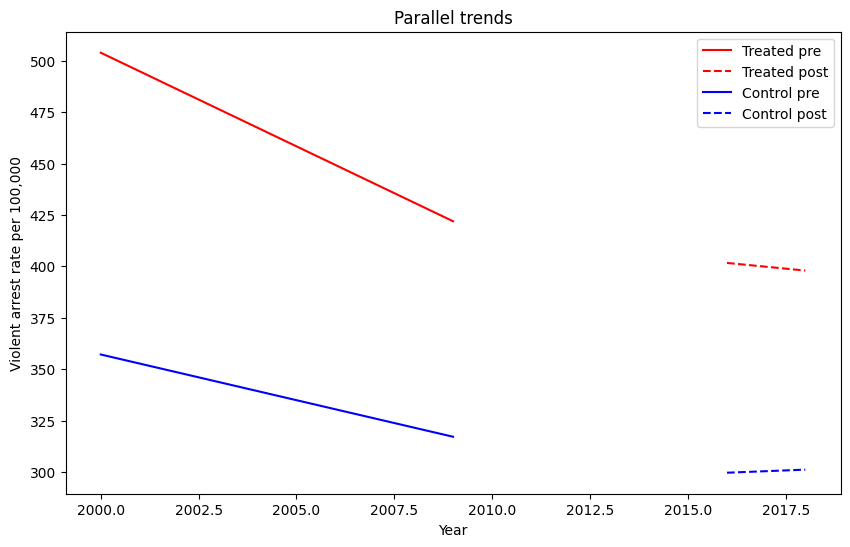

In [39]:
plot_data = data[
    data["YEAR"].between(2000, 2009) | data["YEAR"].between(2016, 2018)
].copy()

yearly_avg = plot_data.groupby(["YEAR", "treated"])["violent_rate"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for treated_val, color, label in [(True, "red", "Treated"), (False, "blue", "Control")]:
    group = yearly_avg[yearly_avg["treated"] == treated_val]

    # pre 2010
    pre = group[group["YEAR"] <= 2009]
    fit = smf.ols("violent_rate ~ YEAR", data=pre).fit()
    ax.plot(pre["YEAR"], fit.fittedvalues, color=color, label=f"{label} pre")

    # post 2016
    post = group[group["YEAR"] >= 2016]
    fit = smf.ols("violent_rate ~ YEAR", data=post).fit()
    ax.plot(
        post["YEAR"],
        fit.fittedvalues,
        color=color,
        linestyle="--",
        label=f"{label} post",
    )

ax.set_xlabel("Year")
ax.set_ylabel("Violent arrest rate per 100,000")
ax.set_title("Parallel trends")
ax.legend()
plt.show()

We see parallel trends (similar sloped lines) for the pre and post datasets, meaning it gives more confidence in the DiD estimate. In the absence of legalization/treatment, the treated and control groups would have followed the same trend over time.

## Diff-in-Diff Event Study Plots

Above, we:

- Estimated a simple two-period, two-group difference in difference estimate, and
- Plotted the raw pre-and-post treatment trends for both groups to evaluate parallel trends.

Many difference-in-difference papers increasingly like to include difference-in-difference "event study" plots. This is accomplished by creating indicators for the difference between treatment and control for different lags pre-and-post treatment. For example, Figure 57 from *Causal Mixtape*:

![causal mixtape lead plot](https://raw.githubusercontent.com/nickeubank/ds4humans/refs/heads/main/99_exercises/images/diff_in_diff_leadplot.png)

These are created by adding indicators for different periods of time before and after treatment began.

More specifically, the estimating equation is:

$$Y_{i,t} = \gamma_i + \lambda_t + \sum_{\tau=-q}^{-1} \gamma_\tau D_{i\tau} + \sum_{\tau=0}^{m} \delta_\tau
  D_{i\tau} + \varepsilon_{i,t}$$

Where $q$ is the number of anticipatory (negative) lags, $m$ is the number of post-treatment (positive) lags. $i$ indexes entities, $t$ indexes time, $\tau$ is time from initiation of treatment, and $\gamma_i$ and $\lambda_t$ are entity and time fixed effects, respectively.

This design has three advantages:

1. it is usable when treatment starts at different times for different units, as a result of which these are often called *staggered* diff-in-diff models,
2. you get standard errors on how different treatment and control are during the pre-treatment period (making it easier to evaluate whether pre-treatment trends are parallel), and
3. you get estimates of the treatment effect at different periods post-treatment, allowing one to examine how the treatment effect may change over time.

The only downside is that when you estimate so many parameters, you need a little more data to get good standard errors than if you'd imposed linearity on the trends.


### Estimating Event-Study Diff-in-Diff

While this is just a lot of indicator variables, and so we could estimate it easily with statsmodels, it can require a lot of keeping track of coefficients to make a nice plot. Instead, let's use the `causalpy` package from PyMC labs, which will make the plot very easily.

PyMC labs is the custodian of some of the best Bayesian Python inference packages (namely [PyMC](https://www.pymc.io/welcome.html)), but they've built this library to also work with frequentist machinery.

In particular, we'll be using their [StaggeredDifferenceInDifferences](https://causalpy.readthedocs.io/en/stable/notebooks/staggered_did_pymc.html) function.

Note: if you go to the documentation for this, you'll find some discussion of some of the subtle issues that arise in a traditional difference-in-difference framework. Their model is doing something just a little more complicated to do their estimation than what we were doing above, though I don't think it's worth getting into the details. If you want to get into the weeds of the technical nuances behind difference-in-difference estimators, you can read the paper they link in their documentation, or you may find [this review](https://yiqingxu.org/papers/english/2023_panel/CLLX_post.pdf) useful.

### Exercise 7

Make a Diff-in-Diff Event Study plot.

To make this work, you'll want to import `LinearRegression` from `sklearn` and pass it to the `model` argument, as illustrated [here](https://causalpy.readthedocs.io/en/stable/notebooks/did_skl.html).

Then you will need to specify four additional arguments:

- `formula`: you can use `"violent_rate ~ 1 + C(COUNTY) + C(YEAR)"`. Note we don't include `treated` in this formula.
- `unit_variable_name`, `time_variable_name`, and `treated_variable_name`

Where `treated_variable_name` is just each unit's treatment status for each observation (e.g. `post_2010 * treated`).

Fit the model, then call:

```python
fig, ax = result.plot()
```

to get your staggered Diff-in-Diff Event Study plot!

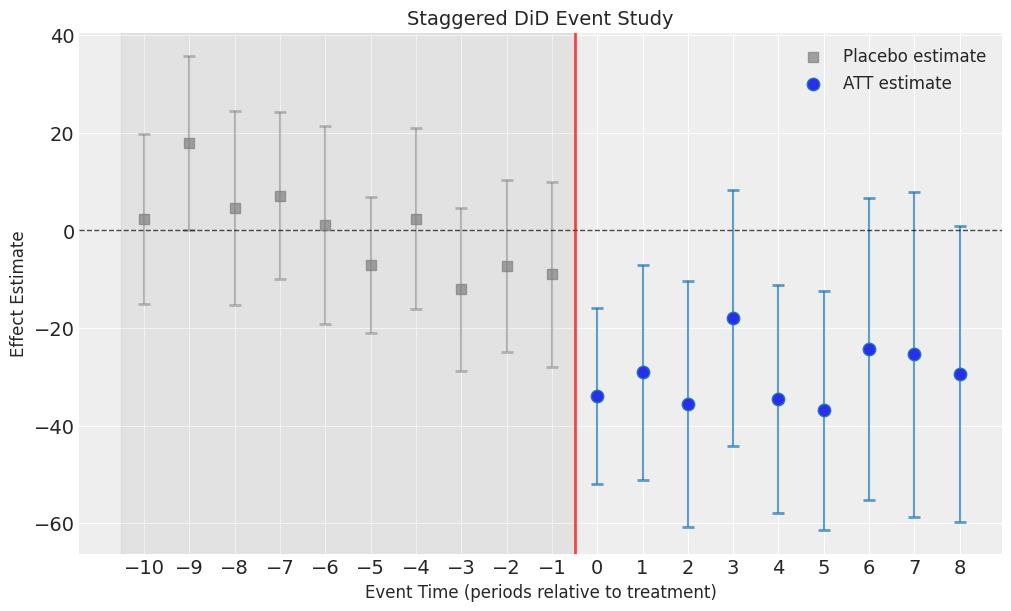

<Figure size 640x480 with 0 Axes>

In [40]:
# event_data = data.copy()
event_data = data[data["YEAR"].between(2000, 2018)].copy()
event_data["post_2010"] = (event_data["YEAR"] >= 2010).astype(int)
event_data["treated_int"] = event_data["treated"].astype(int)
event_data["treatment_status"] = event_data["post_2010"] * event_data["treated_int"]

result = cp.StaggeredDifferenceInDifferences(
    data=event_data,
    formula="violent_rate ~ 1 + C(COUNTY) + C(YEAR)",
    time_variable_name="YEAR",
    unit_variable_name="COUNTY",
    treated_variable_name="treatment_status",
    model=LinearRegression(),
)

fig, ax = result.plot()
plt.tight_layout()

In [41]:
result.summary()

======================Staggered Difference in Differences=======================
Formula: violent_rate ~ 1 + C(COUNTY) + C(YEAR)
Number of units: 58
Number of time periods: 19
Treatment cohorts: [np.float64(2010.0)]
Never-treated units: 29

Event-time estimates:
 event_time    type        att   att_std  n_obs
        -10 placebo   2.360822 47.852991     29
         -9 placebo  17.890333 48.822998     29
         -8 placebo   4.586644 54.492763     29
         -7 placebo   7.138430 46.980099     29
         -6 placebo   1.126506 55.538276     29
         -5 placebo  -7.071791 38.399337     29
         -4 placebo   2.384614 51.009807     29
         -3 placebo -12.108665 45.802519     29
         -2 placebo  -7.324841 48.372579     29
         -1 placebo  -8.982052 52.141240     29
          0     ATT -33.972178 49.399113     29
          1     ATT -29.092518 60.431494     29
          2     ATT -35.501254 69.243032     29
          3     ATT -18.000174 71.913816     29
          4     A

In [42]:
# extract coeffs from result
result.data_

,YEAR,COUNTY,VIOLENT,F_DRUGOFF,total_population,drug_rate,treated,violent_rate,post_2010,treated_int,treatment_status,G,event_time,_is_untreated,y_hat0,tau_hat
obs_ind,,,,,,,,,,,,,,,,
20,2000,Alameda County,4356,7414,1443741.0,513.527011,True,301.716167,0,1,0,2010.0,-10.0,True,311.272432,NaN
21,2001,Alameda County,4478,6486,1450394.0,447.188833,True,308.743693,0,1,0,2010.0,-9.0,True,321.892152,NaN
22,2002,Alameda County,4424,6414,1457047.0,440.205429,True,303.627817,0,1,0,2010.0,-8.0,True,319.140840,NaN
23,2003,Alameda County,4749,6708,1463700.0,458.290633,True,324.451732,0,1,0,2010.0,-7.0,True,307.675562,NaN
24,2004,Alameda County,4301,6886,1470353.0,468.322913,True,292.514791,0,1,0,2010.0,-6.0,True,303.916571,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2257,2014,Yuba County,392,329,72155.0,455.962858,True,543.274894,1,1,1,2010.0,4.0,False,665.264324,-121.989430
2258,2015,Yuba County,454,194,72155.0,268.865636,True,629.201026,1,1,1,2010.0,5.0,False,670.884159,-41.683134
2259,2016,Yuba County,491,154,72155.0,213.429423,True,680.479523,1,1,1,2010.0,6.0,False,670.280132,10.199392


In [43]:
print(result.effect_summary)

<bound method StaggeredDifferenceInDifferences.effect_summary of <causalpy.experiments.staggered_did.StaggeredDifferenceInDifferences object at 0x7f8d9ff82840>>


In [44]:
print(result.att_event_time_)

    event_time        att    att_std  n_obs
0          -10   2.360822  47.852991     29
1           -9  17.890333  48.822998     29
2           -8   4.586644  54.492763     29
3           -7   7.138430  46.980099     29
4           -6   1.126506  55.538276     29
5           -5  -7.071791  38.399337     29
6           -4   2.384614  51.009807     29
7           -3 -12.108665  45.802519     29
8           -2  -7.324841  48.372579     29
9           -1  -8.982052  52.141240     29
10           0 -33.972178  49.399113     29
11           1 -29.092518  60.431494     29
12           2 -35.501254  69.243032     29
13           3 -18.000174  71.913816     29
14           4 -34.529214  64.194223     29
15           5 -36.892662  67.250889     29
16           6 -24.226417  84.942147     29
17           7 -25.420990  91.275102     29
18           8 -29.437894  83.422524     29


In [45]:
# post = result.att_event_time_[result.att_event_time_["event_time"] >= 0]

# results["ex7_diff_in_diff"] = post["att"].mean()

# results["ex7_standard_error"] = post["att_std"].mean()

# results["ex7_new_se"] = post["att_std"].mean() / np.sqrt(len(post))

# print(results["ex7_diff_in_diff"])
# print(results["ex7_standard_error"])
# print(results["ex7_new_se"])

In [46]:
# assert set(results.keys()) == {
#     "ex2_median",
#     "ex4_diff_in_diff",
#     "ex4_y_t0_post",
#     "ex4_y_t0_pre",
#     "ex4_y_t1_post",
#     "ex4_y_t1_pre",
#     "ex5_interaction_coefficient",
#     "ex5_standard_error",
# }

In [47]:
results

{'ex2_median': 301.8092992253924,
 'ex4_y_t0_pre': np.float64(319.7820091530654),
 'ex4_y_t1_pre': np.float64(426.610957589596),
 'ex4_y_t0_post': np.float64(300.4004205665927),
 'ex4_y_t1_post': np.float64(399.81130751911854),
 'ex4_diff_in_diff': np.float64(-7.418061484004738),
 'ex5_interaction_coefficient': np.float64(-7.418061484004955),
 'ex5_standard_error': np.float64(18.86916929287029)}